In [1]:
#week 1-Data Cleaning Completed
import yfinance as yf      # to download stock data
import pandas as pd       # for data handling
import numpy as np        # for calculations
import matplotlib.pyplot as plt   # for graphs
import seaborn as sns     # for advanced visuals

In [2]:
stocks = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'AMZN']

In [4]:
data = yf.download(stocks, start="2022-01-01", end="2024-01-01")

data.columns

[*********************100%***********************]  5 of 5 completed


MultiIndex([( 'Close',  'AAPL'),
            ( 'Close',  'AMZN'),
            ( 'Close', 'GOOGL'),
            ( 'Close',  'MSFT'),
            ( 'Close',  'TSLA'),
            (  'High',  'AAPL'),
            (  'High',  'AMZN'),
            (  'High', 'GOOGL'),
            (  'High',  'MSFT'),
            (  'High',  'TSLA'),
            (   'Low',  'AAPL'),
            (   'Low',  'AMZN'),
            (   'Low', 'GOOGL'),
            (   'Low',  'MSFT'),
            (   'Low',  'TSLA'),
            (  'Open',  'AAPL'),
            (  'Open',  'AMZN'),
            (  'Open', 'GOOGL'),
            (  'Open',  'MSFT'),
            (  'Open',  'TSLA'),
            ('Volume',  'AAPL'),
            ('Volume',  'AMZN'),
            ('Volume', 'GOOGL'),
            ('Volume',  'MSFT'),
            ('Volume',  'TSLA')],
           names=['Price', 'Ticker'])

In [5]:
data = data['Close']

In [6]:
data.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2022-01-03,178.103653,170.404495,143.802963,323.160858,399.926666
2022-01-04,175.843231,167.522003,143.215820,317.619568,383.196655
2022-01-05,171.165833,164.356995,136.645630,305.426697,362.706665
2022-01-06,168.308517,163.253998,136.618347,303.013306,354.899994
2022-01-07,168.474838,162.554001,135.893845,303.167786,342.320007


In [7]:
data = data.dropna()

In [8]:
data.isnull().sum()

Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
TSLA     0
dtype: int64

In [11]:
data.to_csv("clean_stock_data.csv")

In [12]:
data = yf.download(stocks, start="2022-01-01", end="2024-01-01", auto_adjust=True)

[*********************100%***********************]  5 of 5 completed


In [13]:

data = data['Close']

In [14]:
data = data.dropna()

In [15]:
data.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2022-01-03,178.103653,170.404495,143.802963,323.160858,399.926666
2022-01-04,175.843231,167.522003,143.215820,317.619568,383.196655
2022-01-05,171.165833,164.356995,136.645630,305.426697,362.706665
2022-01-06,168.308517,163.253998,136.618347,303.013306,354.899994
2022-01-07,168.474838,162.554001,135.893845,303.167786,342.320007


In [ ]:
#week 2- Quantitative analysis

In [10]:
#week 2- Quantitative analysis
returns = data.pct_change()
returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.012692,-0.016916,-0.004083,-0.017147,-0.041833
2022-01-05,-0.026600,-0.018893,-0.045876,-0.038388,-0.053471
2022-01-06,-0.016693,-0.006711,-0.000200,-0.007902,-0.021523
2022-01-07,0.000988,-0.004288,-0.005303,0.000510,-0.035447


In [16]:
returns = returns.dropna()

In [17]:
returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2022-01-04,-0.012692,-0.016916,-0.004083,-0.017147,-0.041833
2022-01-05,-0.026600,-0.018893,-0.045876,-0.038388,-0.053471
2022-01-06,-0.016693,-0.006711,-0.000200,-0.007902,-0.021523
2022-01-07,0.000988,-0.004288,-0.005303,0.000510,-0.035447
2022-01-10,0.000116,-0.006570,0.012060,0.000732,0.030342


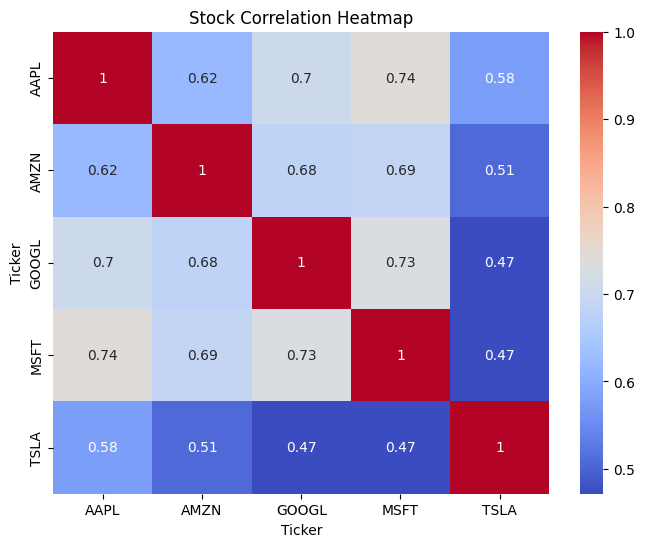

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Correlation Heatmap")
plt.show()

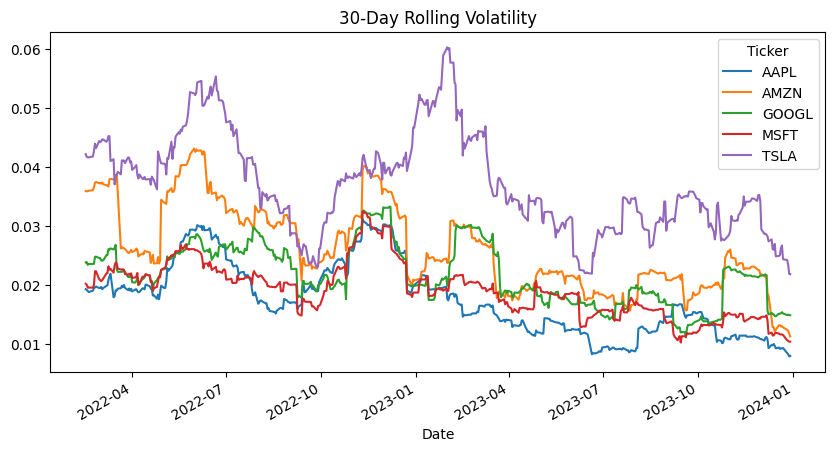

In [19]:
volatility = returns.rolling(window=30).std()

volatility.plot(figsize=(10,5))
plt.title("30-Day Rolling Volatility")
plt.show()

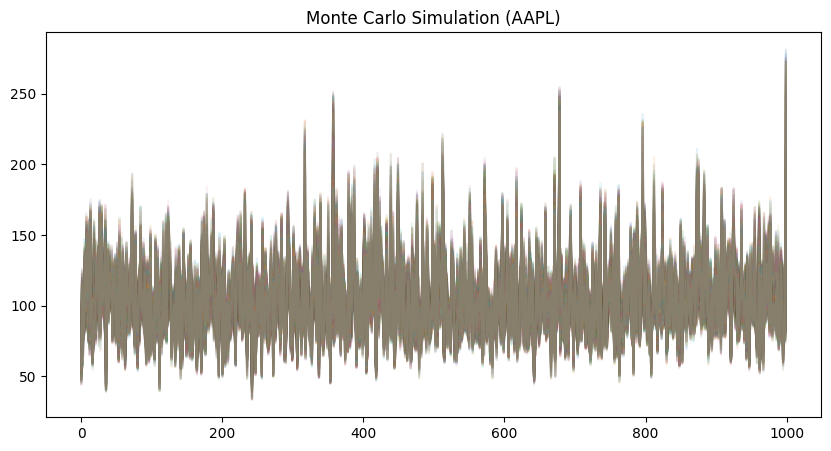

In [20]:
# Monte Carlo Simulation
import numpy as np

stock = returns['AAPL']

mean = stock.mean()
std = stock.std()

simulations = 1000
days = 252

results = []

for i in range(simulations):
    price = 100
    prices = []
    
    for j in range(days):
        price = price * (1 + np.random.normal(mean, std))
        prices.append(price)
    
    results.append(prices)

plt.figure(figsize=(10,5))
plt.plot(results, alpha=0.1)
plt.title("Monte Carlo Simulation (AAPL)")
plt.show()

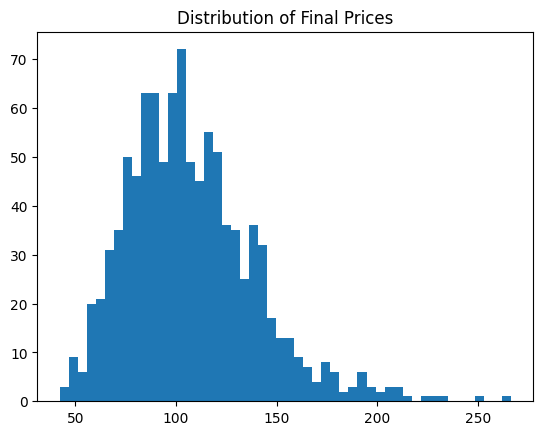

In [22]:
# Distribution of final prices (Histogram)

final_prices = [sim[-1] for sim in results]

plt.hist(final_prices, bins=50)
plt.title("Distribution of Final Prices")
plt.show()

In [23]:
log_returns = np.log(data / data.shift(1))
log_returns = log_returns.dropna()

In [24]:
from scipy.stats import skew, kurtosis

final_prices = [sim[-1] for sim in results]

print("Skewness:", skew(final_prices))
print("Kurtosis:", kurtosis(final_prices))

Skewness: 0.9169453327624204
Kurtosis: 1.5188990802982287
